In [1]:
import os
import sys

sys.path.insert(0, os.path.dirname(os.getcwd()))
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "testing"))
sys.path = list(set(sys.path))
from testing.test import *
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RESULTS_DIR = r"\\znas\Lab\Share\UNITMATCHTABLES_ENNY_CELIAN_JULIE\DeepUM_NatMeth2026_V3_OnMergedData\results"

In [23]:
def snap_to_bin(days, bin_edges, bin_centers):
    idx = np.digitize(days, bin_edges).clip(1, len(bin_centers)) - 1
    return bin_centers[idx]

def get_binned_data_merged(data, col, bin_edges):
    unique_mice = data["mouse"].unique()
    all_points = []
    for mouse in unique_mice:
        mouse_data = data[data["mouse"] == mouse]
        bin_indices = np.digitize(mouse_data["delta_days"], bin_edges)
        for bin_idx in range(1, len(bin_edges)):
            bin_data = mouse_data[bin_indices == bin_idx]
            if len(bin_data) > 0:
                all_points.append(
                    {
                        "mouse": mouse,
                        "bin_idx": bin_idx,
                        "bin_center": bin_centers[bin_idx - 1],
                        "AUC": bin_data[col].mean(),
                        "count": len(bin_data),
                    }
                )
    return pd.DataFrame(all_points)

In [62]:

dum_path = os.path.join(RESULTS_DIR, r"UM Probabilities_DeepUnitMatch_results_BU.csv")
um_path = os.path.join(RESULTS_DIR, r"UM Probabilities_UMPy_results_BU.csv")

dum = pd.read_csv(dum_path).drop_duplicates()
um = pd.read_csv(um_path).drop_duplicates()

merged = dum.merge(um, on=["mouse", "probe", "loc", "r1", "r2"], suffixes=("", "_UM"))
merged = merged.loc[((merged["N"] > 19) | (merged["N_UM"] > 19))]

merged_AL032 = merged.loc[(merged["mouse"] == "AL032")]

bin_edges = np.array([1, 2, 4, 8, 16, 32, 64, 128, 256])
bin_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])

x = snap_to_bin(merged["delta_days"].values, bin_edges, bin_centers)
x_AL032 = snap_to_bin(merged_AL032["delta_days"].values, bin_edges, bin_centers)

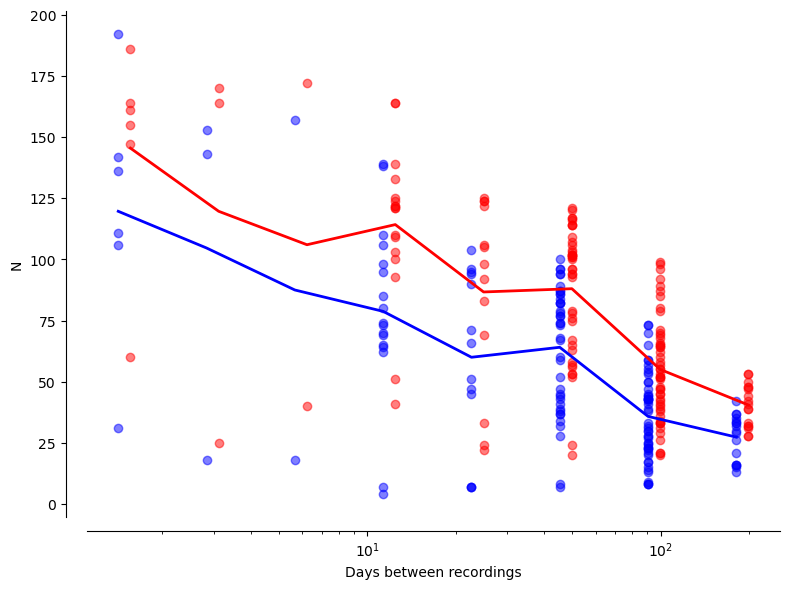

In [ ]:
quantity = "N" # Figure 3a
# quantity = 'AUCisi' # Figure 3b

plt.figure(figsize=(8, 6))

plt.scatter(
    x_AL032 * 1.1, 
    merged_AL032[quantity].values, 
    color="red", 
    edgecolor="red", 
    alpha=0.5, 
    label="DUM"
    )
plt.scatter(
    x_AL032, 
    merged_AL032[quantity + "_UM"].values, 
    color="blue", 
    edgecolor="blue", 
    alpha=0.5, 
    label="UM"
    )

for col, jitter, color in [(quantity, 1.1, "red"), (quantity + "_UM", 1.0, "blue")]:
    pts = pd.DataFrame({"bin_center": x_AL032, "values": merged_AL032[col].values})
    avg = pts.groupby("bin_center")["values"].mean().reset_index()
    plt.plot(avg["bin_center"] * jitter, avg["values"], color=color, linewidth=2)

plt.xscale("log")
plt.xlabel("Days between recordings")
plt.ylabel(quantity)
plt.grid(False)
ax = plt.gca()
ax.spines[["right", "top"]].set_visible(False)
ax.spines["left"].set_position(("outward", 15))
ax.spines["bottom"].set_position(("outward", 10))
plt.rcParams["svg.fonttype"] = "none"
plt.tight_layout()
plt.show()

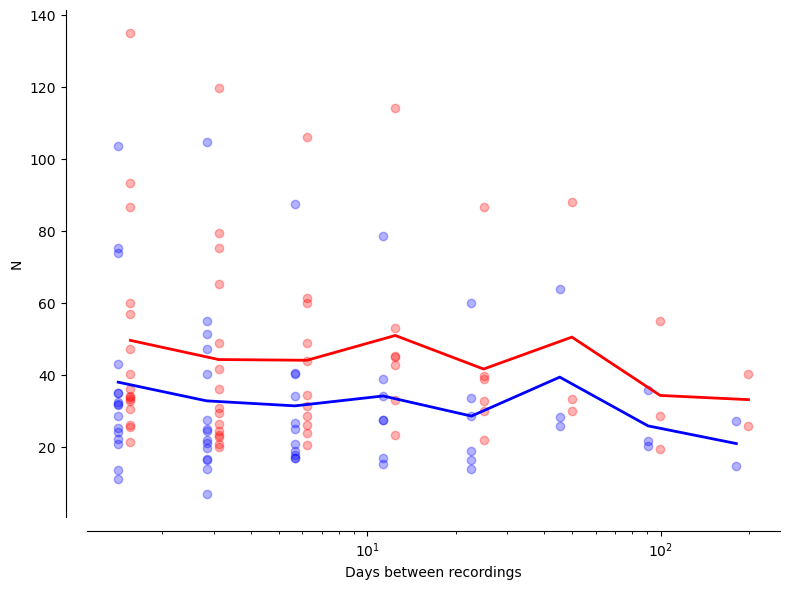

In [ ]:
quantity = "N" # Figure 3c
# quantity = "AUCisi" # Figure 3d

points_dum = get_binned_data_merged(merged, quantity, bin_edges)
points_um = get_binned_data_merged(merged, quantity + "_UM", bin_edges)

plt.figure(figsize=(8, 6))

plt.scatter(
    points_dum["bin_center"] * 1.1,
    points_dum["AUC"],
    color="red",
    edgecolor="red",
    alpha=0.3,
    label=f"DUM (n={points_dum['mouse'].nunique()} mice)",
)
plt.scatter(
    points_um["bin_center"],
    points_um["AUC"],
    color="blue",
    alpha=0.3,
    label=f"UM (n={points_um['mouse'].nunique()} mice)",
)

avg_dum = (
    points_dum.groupby("bin_center").agg({"AUC": "mean", "count": "sum"}).reset_index()
)
avg_um = (
    points_um.groupby("bin_center").agg({"AUC": "mean", "count": "sum"}).reset_index()
)
plt.plot(avg_dum["bin_center"] * 1.1, avg_dum["AUC"], color="red", linewidth=2)
plt.plot(avg_um["bin_center"], avg_um["AUC"], color="blue", linewidth=2)

plt.xscale("log")
plt.xlabel("Days between recordings")
plt.ylabel(quantity)
plt.grid(False)
ax = plt.gca()
ax.spines[["right", "top"]].set_visible(False)
ax.spines["left"].set_position(("outward", 15))
ax.spines["bottom"].set_position(("outward", 10))
plt.rcParams["svg.fonttype"] = "none"
plt.tight_layout()
plt.show()